<a href="https://colab.research.google.com/github/sflmnt/Business-Intelligence/blob/main/8.%20ProyectoFinal_Luisa_De_La_Espriella_Y_Sof%C3%ADa_Lomanto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Proyecto Final - Luisa De La Espriella y Sofía Lomanto***
---
Base de datos: https://www.kaggle.com/datasets/orvile/health-and-sleep-relation-2024/data

Modelos a Implementar: Clusterización y Árbol de decisión.

**Definición de las Variables:** El conjunto de datos "Health and Sleep Relation 2024" explora la relación entre los patrones de sueño y la salud general. Incluye información detallada sobre hábitos de sueño, métricas de salud y estilo de vida de individuos, proporcionando una base sólida para analizar cómo el sueño afecta diversos aspectos del bienestar. A continuación vamos a definir nuestras variables de estudio:

* **Gender:** Indica el sexo de la persona. Está codificado como 0 para Masculino (M) y 1 para Femenino (F).

* **Age:** Representa la edad de la persona en años.

* **Sleep Duration:** Es el número promedio de horas que la persona duerme por noche.

* **Quality of Sleep:** Muestra una calificación de la calidad del sueño, posiblemente en una escala del 1 al 10.

* **Physical Activity Level:** Indica el nivel de actividad física de la persona, probablemente en minutos semanales o en una escala numérica.

* **Stress Level:** Refleja el nivel de estrés del individuo, usualmente en una escala de 1 a 10.

* **BMI Category:** Clasifica el Índice de Masa Corporal (IMC) de la persona. Está codificado como: 0 = Normal, 1 = Sobrepeso , 2 = Obesidad

* **Heart Rate:** Indica la frecuencia cardíaca de la persona, es decir, el número de latidos por minuto (bpm). Un rango normal en reposo para adultos es de 60 a 100 bpm.

* **Sleep Disorder:** Indica si la persona sufre de algún trastorno del sueño. Está codificado como: 0 = Ninguno, 1 = Apnea del sueño o Insomnio


**Modelo Árbol de Decisiones**

0. Se procede con la carga de liberias

In [ ]:
#Librerias cientificas
import numpy as np
import pandas as pd

#liberias Arbol
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix

#Conectar al Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


1. Se procede con la carga de los datos

In [ ]:
nxl='/content/drive/MyDrive/Análitica 2025-1/Sleep_health_and_lifestyle_dataset.xlsx'
XDB1=pd.read_excel(nxl,sheet_name=0)
XDB1.dropna()

# Select the features and target variable
XD = XDB1[['Gender','Age','Sleep Duration','Quality of Sleep','Physical Activity Level','Stress Level','BMI Category','Heart Rate']]
yd = XDB1['Sleep Disorder']


display(XDB1.head(100))

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,0,27,Software Engineer,6.1,6,42,6,1,126/83,77,4200,0
1,2,0,28,Doctor,6.2,6,60,8,0,125/80,75,10000,0
2,3,0,28,Doctor,6.2,6,60,8,0,125/80,75,10000,0
3,4,0,28,Sales Representative,5.9,4,30,8,2,140/90,85,3000,1
4,5,0,28,Sales Representative,5.9,4,30,8,2,140/90,85,3000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,1,36,Accountant,7.1,8,60,4,0,115/75,68,7000,0
96,97,1,36,Accountant,7.2,8,60,4,0,115/75,68,7000,0
97,98,1,36,Accountant,7.1,8,60,4,0,115/75,68,7000,0
98,99,1,36,Teacher,7.1,8,60,4,0,115/75,68,7000,0


2. Se procede con la implementación del modelo

In [ ]:
mar=DecisionTreeClassifier(criterion='gini',max_depth=4)
mar.fit(XD,yd)

#Se procede con la gráfica
from pydotplus import graph_from_dot_data
from sklearn.tree import export_graphviz

ve=['Gender','Age','Sleep Duration','Quality of Sleep','Physical Activity Level','Stress Level','BMI Category','Heart Rate']
dot_data=export_graphviz(mar,feature_names=ve)#crear gráfico
graph=graph_from_dot_data(dot_data)
graph.write_png('ÁrbolDecisión-Parcial Final.png')

True

3. Se procede con la evaluación del modelo

In [ ]:
ydp=mar.predict(XD) #Pronóstico sobre la base de datos original
cm=confusion_matrix(yd,ydp) #Matriz de confusión
print("La matriz de confusión es: \n",cm)

VN=cm[0,0] #Verdaderos Negativos
VP=cm[1,1] #Verdaderos Positivos
FP=cm[0,1] #Falsos Positivos
FN=cm[1,0] #Falsos Negativos

Exactitud=(VP+VN)/(VP+VN+FP+FN)
print("La exactitud es: ",Exactitud)

Sensibilidad=VP/(VP+FN)
print("La sensibilidad es: ",Sensibilidad)

Especificidad=VN/(VN+FP)
print("La especificidad es: ",Especificidad)

Precision=VP/(VP+FP)
print("La precisión es: ",Precision)

TasaError=(FP+FN)/(VP+VN+FP+FN)
print("La tasa de error es:",TasaError)


La matriz de confusión es: 
 [[210   9]
 [ 12 143]]
La exactitud es:  0.9438502673796791
La sensibilidad es:  0.9225806451612903
La especificidad es:  0.958904109589041
La precisión es:  0.9407894736842105
La tasa de error es: 0.05614973262032086


4. Estudiamos nuestros resultados para entender la variable de salida en nosotras

In [ ]:
#Luisa
XDS=[1,21,5,4,30,8,0,88]
print("los datos del candidato son :\n", XDS)
# Reshape XDS to a 2D array with one row and multiple columns
XDS = np.array(XDS).reshape(1, -1)
ydp=mar.predict(XDS) #Se obtiene la predicción
print("la predicción del candidato es :\n", ydp)

if ydp==1:
  print("Esta persona padece de insomnia o apnea del sueño")
else:
  print("Esta persona NO padece de insomnia o apnea del sueño")

los datos del candidato son :
 [1, 21, 5, 4, 30, 8, 0, 88]
la predicción del candidato es :
 [1]
Esta persona padece de insomnia o apnea del sueño


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


_________________________________________________________________________________________________________________________________________






In [ ]:
#Sofia
XDS1=[1,20,7,7,30,3,0,82]
print("los datos del candidato son :\n", XDS1)
# Reshape XDS to a 2D array with one row and multiple columns
XDS1 = np.array(XDS1).reshape(1, -1)
ydp=mar.predict(XDS1) #Se obtiene la predicción
print("la predicción del candidato es :\n", ydp)

if ydp==1:
  print("Esta persona padece de insomnia o apnea del sueño")
else:
  print("Esta persona NO padece de insomnia o apnea del sueño")

los datos del candidato son :
 [1, 20, 7, 7, 30, 3, 0, 82]
la predicción del candidato es :
 [0]
Esta persona NO padece de insomnia o apnea del sueño


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


**Análisis de Resultados: Árboles de Decisión**

La matriz de confusión muestra una predominancia por los valores verdadero negativos, con una presencia de 210 datos, mientras que los valores verdaderos positivos de segundo lugar con 143 datos. Por otro lado, el modelo alcanzo valores por encima del 90%  para los indices de exactitud(94%), sensibilidad(92%), precision(94%), y especificidad(95%), lo que muestra claramente el buen funcionamiento del modelo frente al pronóstico de si las personas presentan o no desordenes de sueño. Asimismo, también se puede resaltar un valor de la tasa de error, que se encontró en valores de 0%, exactamente (0,05%), lo cual demuestra la eficiencia del modelo.

Adicionalmente, en el árbol de decisiones identificamos la presencia de 6 nodos puros, los cuales indican que esas personas padecen de trastornos del sueño.

Por otro lado, decidimos hacer un pronóstico para dos aplicantes nuevos, para ver las habilidades del modelo, de los cuales concluimos lo siguientre:

Luisa : [1,21,5,4,30,8,0,88]*

Con la información suministrada, el modelo establecido que esta persona, presenta desordenes del sueño.

Sofia: [1,20,7,7,30,3,0,82]*

Con la información suministrada por esta persona, el modelo llego a la conclusión de que ella NO padece o presenta desordenes del sueño

*Los datos están organizado en la misma forma de la lista de la variables de entrada.


# **Modelo de Clusterización:**

0. Se cargan las librerias de trabajo

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Se procede con la implementación del modelo
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1. Se cargan los datos

,Gender,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Sleep Disorder
0,0,27,6.1,6,42,6,1,77,0
1,0,28,6.2,6,60,8,0,75,0
2,0,28,6.2,6,60,8,0,75,0
3,0,28,5.9,4,30,8,2,85,1
4,0,28,5.9,4,30,8,2,85,1
...,...,...,...,...,...,...,...,...,...
369,1,59,8.1,9,75,3,1,68,1
370,1,59,8.0,9,75,3,1,68,1
371,1,59,8.1,9,75,3,1,68,1
372,1,59,8.1,9,75,3,1,68,1


/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


<Figure size 640x480 with 0 Axes>

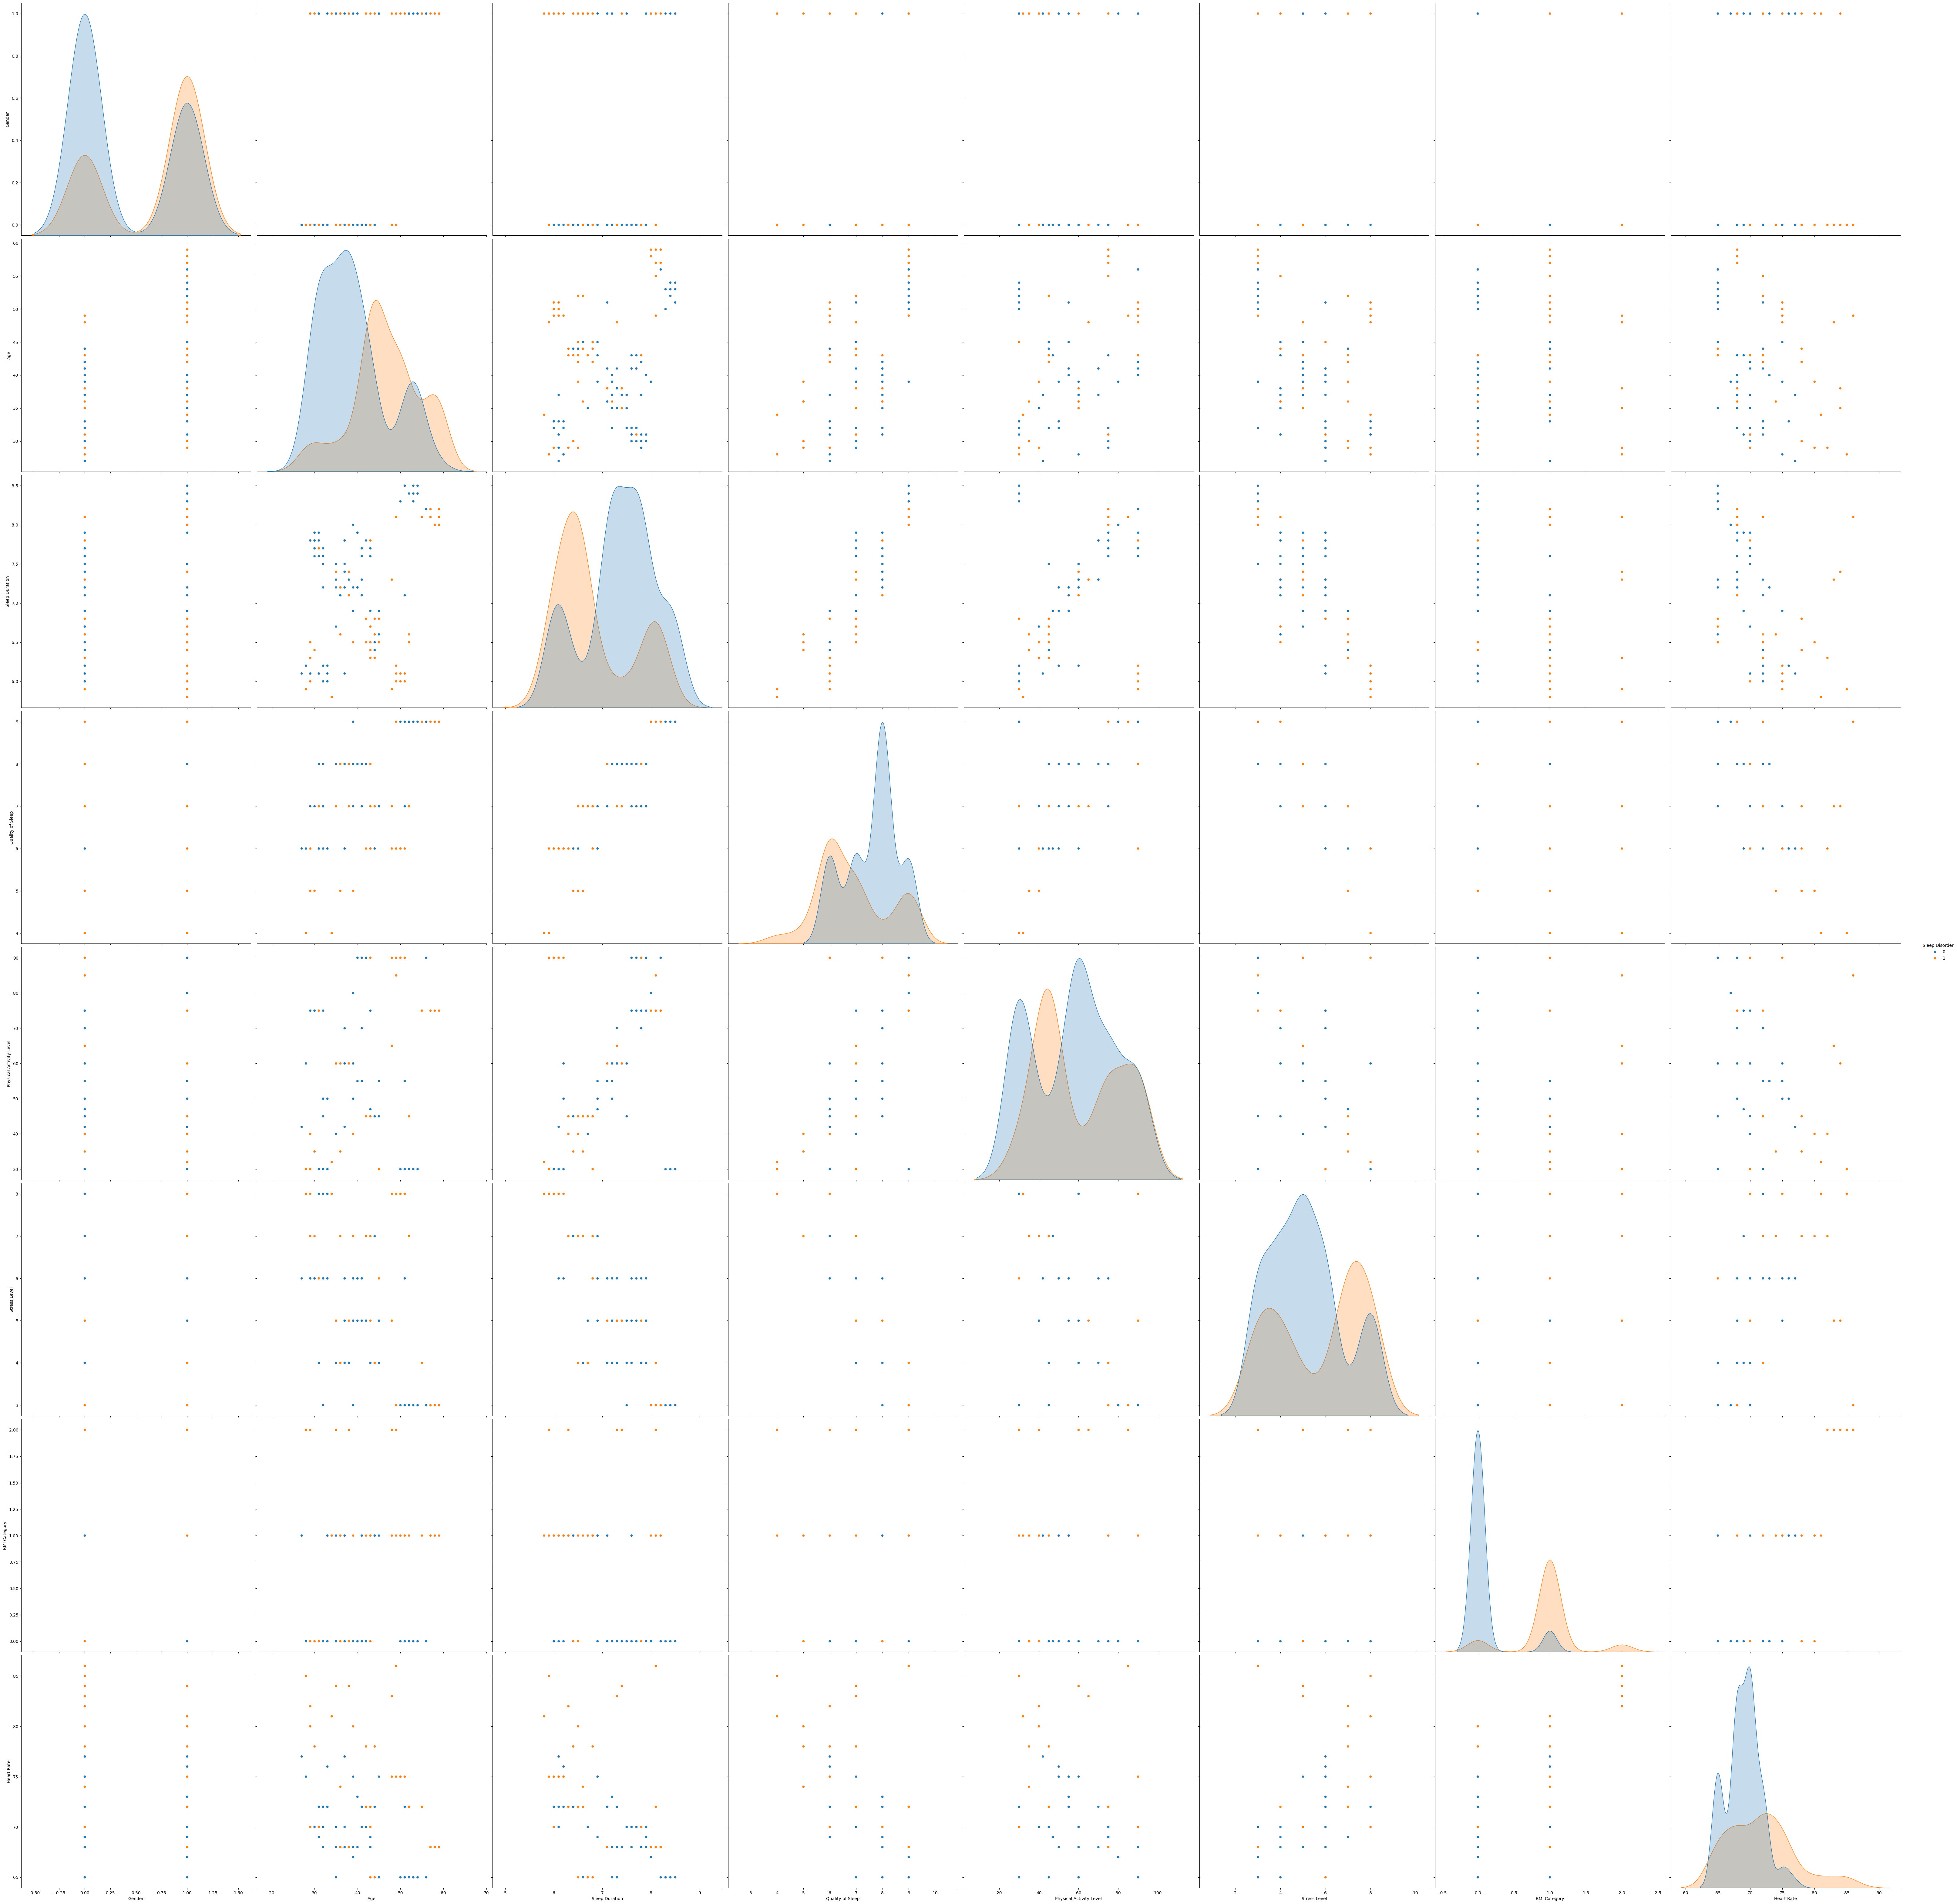

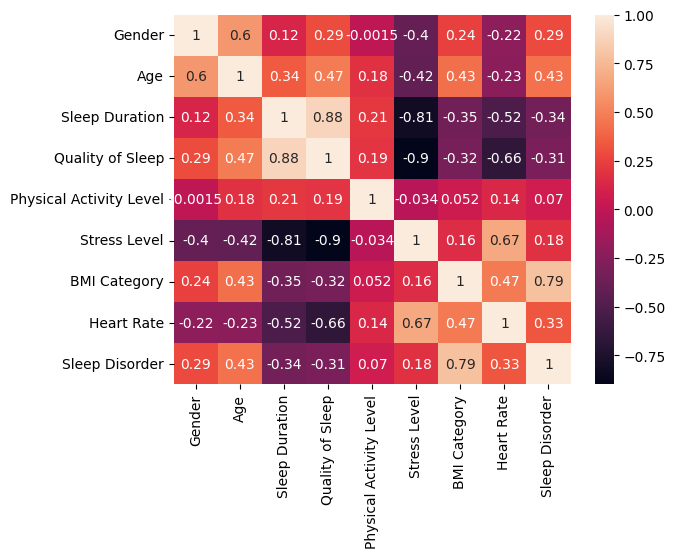

In [ ]:
nxl='/content/drive/MyDrive/Análitica 2025-1/Sleep_health_and_lifestyle_dataset.xlsx'
XDB=pd.read_excel(nxl,sheet_name=0)
XDB=XDB[['Gender','Age','Sleep Duration','Quality of Sleep','Physical Activity Level','Stress Level','BMI Category','Heart Rate', 'Sleep Disorder']]
XDB.dropna()
display(XDB)

#Para mirar correlaciones y variables importantes
plt.figure()
sns.pairplot(XDB,hue='Sleep Disorder',size=8,vars=['Gender','Age','Sleep Duration','Quality of Sleep','Physical Activity Level','Stress Level','BMI Category','Heart Rate']) #EL # de variables y el nombre
plt.show()

#Cuales son las correlaciones (mientras más cercano a 1 , más correlación)
plt.figure()
sns.heatmap(XDB.corr(),annot=True)
plt.show()

2. Se procede con la implementación del modelo de clusterización

In [ ]:
XD = XDB1[['Gender','Age','Sleep Duration','Quality of Sleep','Physical Activity Level','Stress Level','BMI Category','Heart Rate']]
yd = XDB1['Sleep Disorder']

#Se van a crear 5 montoncitos de datos (perfiles de crédito)
np.random.seed(42)
nc=5
mkm=KMeans(n_clusters=nc,random_state=42)
mkm.fit(XD,yd)
centroids=mkm.cluster_centers_
print("los centroides son :\n",centroids)

#como quedaron clasificadas las personas
labels=mkm.labels_
XDB['labels']=labels #Adicione a la tabla el cluster al que pertenece un solicitante
display(XDB)

#Caracterizamos los centroides
ND=np.bincount(labels)
print("El tamaño de los clusters es:\n",ND)
NApr=XDB.groupby('labels').agg({"Sleep Disorder":lambda x:(x==1).sum()})
NNeg=XDB.groupby('labels').agg({"Sleep Disorder":lambda x:(x==0).sum()})
print("El número de personas con desordenes de sueño por cluster es:\n",NApr)
print("El número de personas sin desordenes de sueño por cluster es:\n",NNeg)

#Se procede con la estimación de los porcentajes de PreAprobación
NApr['Sleep Disorder']=NApr['Sleep Disorder']/ND
NNeg['Sleep Disorder']=NNeg['Sleep Disorder']/ND
print("El porcentaje de personas con desordenes de sueño por cluster es:\n",NApr)
print("El porcentaje de personas sin desordenes de sueño por cluster es:\n",NNeg)

los centroides son :
 [[ 0.34188034 35.47008547  7.34273504  7.5982906  64.23076923  5.02564103
   0.11965812 69.48717949]
 [ 0.50704225 46.04225352  7.02112676  7.18309859 89.57746479  6.18309859
   0.50704225 72.42253521]
 [ 0.14       31.8         6.188       5.78       32.76        7.44
   0.34       73.94      ]
 [ 0.66990291 47.11650485  7.11941748  7.2815534  40.21359223  4.99029126
   0.66019417 68.16504854]
 [ 1.         58.03030303  8.09393939  9.         75.          3.06060606
   1.         68.24242424]]


,Gender,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Sleep Disorder,labels
0,0,27,6.1,6,42,6,1,77,0,2
1,0,28,6.2,6,60,8,0,75,0,0
2,0,28,6.2,6,60,8,0,75,0,0
3,0,28,5.9,4,30,8,2,85,1,2
4,0,28,5.9,4,30,8,2,85,1,2
...,...,...,...,...,...,...,...,...,...,...
369,1,59,8.1,9,75,3,1,68,1,4
370,1,59,8.0,9,75,3,1,68,1,4
371,1,59,8.1,9,75,3,1,68,1,4
372,1,59,8.1,9,75,3,1,68,1,4


El tamaño de los clusters es:
 [117  71  50 103  33]
El número de personas con desordenes de sueño por cluster es:
         Sleep Disorder
labels                
0                    9
1                   36
2                   15
3                   65
4                   30
El número de personas sin desordenes de sueño por cluster es:
         Sleep Disorder
labels                
0                  108
1                   35
2                   35
3                   38
4                    3
El porcentaje de personas con desordenes de sueño por cluster es:
         Sleep Disorder
labels                
0             0.076923
1             0.507042
2             0.300000
3             0.631068
4             0.909091
El porcentaje de personas sin desordenes de sueño por cluster es:
         Sleep Disorder
labels                
0             0.923077
1             0.492958
2             0.700000
3             0.368932
4             0.090909


3. Se procede a evaluar el modelo (matriz de confusión)

In [ ]:
ydp=np.zeros((len(XD),1))
Vapr=np.array(NApr); Vneg=np.array(NNeg)

for k in range(len(XD)):
  napr=labels[k]
  print("La persona tal:",k)
  print("El cluster al que pertenece es:",napr)
  print("El porcentaje de tener desordenes de sueño es:",Vapr[napr])
  print("El porcentaje de no tener desordenes de sueño es:",Vneg[napr])

#Consolidamos la información de los Aprobados y Negadps
  if Vapr[napr]>Vneg[napr]:
    ydp[k]=1
  else:
    ydp[k]=0


#Se evalua el modelo
cm=confusion_matrix(yd,ydp)
print("La matriz de confusión es:\n",cm)

VN=cm[0,0]
FP=cm[0,1]
FN=cm[1,0]
VP=cm[1,1]

Exactitud=(VN+VP)/(VN+FP+FN+VP)
Sensibilidad=VP/(VP+FN)
Especificidad=VN/(VN+FP)
Precision=VP/(VP+FP)
TasaError=(FP+FN)/(VN+FP+FN+VP)

print("La exactitud es:",Exactitud)
print("La sensibilidad es:",Sensibilidad)
print("La especificidad es:",Especificidad)
print("La precisión es:",Precision)
print("La tasa de error es:",TasaError)


La persona tal: 0
El cluster al que pertenece es: 2
El porcentaje de tener desordenes de sueño es: [0.3]
El porcentaje de no tener desordenes de sueño es: [0.7]
La persona tal: 1
El cluster al que pertenece es: 0
El porcentaje de tener desordenes de sueño es: [0.07692308]
El porcentaje de no tener desordenes de sueño es: [0.92307692]
La persona tal: 2
El cluster al que pertenece es: 0
El porcentaje de tener desordenes de sueño es: [0.07692308]
El porcentaje de no tener desordenes de sueño es: [0.92307692]
La persona tal: 3
El cluster al que pertenece es: 2
El porcentaje de tener desordenes de sueño es: [0.3]
El porcentaje de no tener desordenes de sueño es: [0.7]
La persona tal: 4
El cluster al que pertenece es: 2
El porcentaje de tener desordenes de sueño es: [0.3]
El porcentaje de no tener desordenes de sueño es: [0.7]
La persona tal: 5
El cluster al que pertenece es: 2
El porcentaje de tener desordenes de sueño es: [0.3]
El porcentaje de no tener desordenes de sueño es: [0.7]
La per

4. Estudiamos nuestros resultados para entender la variable de salida en nosotras

In [ ]:
import numpy as np
# Luisa
XDS= [1, 21, 5, 4, 30, 8, 0, 88]
XDS= np.array(XDS).reshape(1, -1)

# Predict the cluster for the new person
cluster_new_person = mkm.predict(XDS)
print(f"Luisa pertenece al cluster: {cluster_new_person}")

# Get the percentages of having and not having sleep disorders for that cluster
percentage_disorder = Vapr[cluster_new_person[0]].item()
percentage_no_disorder = Vneg[cluster_new_person[0]].item()

print(f"El porcentaje de tener desordenes de sueño es: {percentage_disorder:.2f}")
print(f"El porcentaje de no tener desordenes de sueño es: {percentage_no_disorder:.2f}")

Luisa pertenece al cluster: [2]
El porcentaje de tener desordenes de sueño es: 0.30
El porcentaje de no tener desordenes de sueño es: 0.70


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [ ]:
import numpy as np
# Sofia
XDS1=[1,20,7,7,30,3,0,82]
XDS1= np.array(XDS).reshape(1, -1)

# Predict the cluster for the new person
cluster_new_person = mkm.predict(XDS1)
print(f"Sofia pertenece al cluster: {cluster_new_person}")

# Get the percentages of having and not having sleep disorders for that cluster
percentage_disorder = Vapr[cluster_new_person[0]].item()
percentage_no_disorder = Vneg[cluster_new_person[0]].item()

print(f"El porcentaje de tener desordenes de sueño es: {percentage_disorder:.2f}")
print(f"El porcentaje de no tener desordenes de sueño es: {percentage_no_disorder:.2f}")

Sofia pertenece al cluster: [2]
El porcentaje de tener desordenes de sueño es: 0.30
El porcentaje de no tener desordenes de sueño es: 0.70


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


**Análisis de resultados: Modelo de Clusterización**
Según el modelo de clusterización podemos encontrar que la variable con mayor correlación con nuestra variable de salida (Sleep Disorder) es la variable BMI Category con una correlación de casi 80%, está es la única variable que sobresale frente a la relación con la variable de salida pero también podemos encontrar correlaciones entre las variables de entrada que son importantes como la correlación entra las variables "Quality of sleep" y "Sleep Duration", alcanzando el 88%. Finalmente también sobresale la correlación de las variables "Sleep Duration" y "Quality of sleep" con la variable "Stress Level" que nos indica que los niveles de estres afectan negativamente la duración y la calidad del sueño.

También generamos 5 clusters distintos con tamaño de 117,71,50,103 y 33 respectivamente donde encontramos que el cluster 4 tiene el mayor porcentaje de personas con desordenes de sueño ( el 90,9% de su cluster que corresponde a 30 personas de 33 que hay en total) y el cluster 0 tiene el mayor porcentaje de personas sin desordenes de sueño ( el 92,3% de su cluster que corresponde a 107 personas de 117 en total)

Por último el modelo presento una buena exactitud de alrededor 75% (73,2%), una sensibilidad de 84,5% y una tasa de error de alrededor de 25%, lo que sugiere un buen comportamiento del modelo.

También decidimos estudiar nuestra información contra este modelo, y el determinó que tanto Luisa como Sofía pertenecen al cluster 2 con 70% de no padecer ninguna enfermedad y el 30% de si hacerlo